# <center>Titanic Survival Analysis

## Project Overview

The Titanic dataset contains information about passengers aboard the RMS Titanic, including demographic characteristics, passenger class, fare, and survival status. This project uses exploratory data analysis (EDA) to investigate the factors associated with passenger survival.

The primary purpose of this analysis is to explore whether characteristics such as **passenger class, sex, age, and fare** were associated with differences in survival outcomes. Through data cleaning, descriptive statistics, and visualization, the project aims to identify meaningful patterns and relationships within the dataset.

## Objectives

The objectives of this project are to:

1. **Understand the dataset** by examining its structure, variables, data types, and descriptive statistics.
2. **Assess data quality** by identifying missing values, duplicate records, and potential inconsistencies.
3. **Explore passenger characteristics** such as age, sex, passenger class, and fare.
4. **Analyze survival rates** and determine how survival varied across different passenger groups.
5. **Investigate relationships** between passenger characteristics and survival outcomes using statistical summaries and visualizations.
6. **Identify key patterns and findings** that can help explain differences in survival among passengers.
7. **Communicate the findings** through clear visualizations and data-driven conclusions.

## General Project Outline

The analysis will follow the following workflow:

**1. Data Loading & Understanding**
Load the Titanic dataset and examine its dimensions, columns, data types, and initial records.

**2. Data Cleaning & Preparation**
Identify and address missing values, duplicates, and other data-quality issues before analysis.

**3. Exploratory Data Analysis**
Use descriptive statistics to understand the distribution of passenger characteristics and survival outcomes.

**4. Data Visualization**
Create appropriate visualizations such as bar charts, histograms, box plots, and count plots to explore patterns in the data.

**5. Survival Analysis**
Compare survival outcomes across variables such as sex, passenger class, age, and fare.

**6. Correlation & Relationships**
Examine relationships between relevant numerical variables and consider how they relate to survival.

**7. Key Findings & Conclusions**
Summarize the most important patterns identified during the analysis and distinguish observations supported by the data from assumptions that cannot be established through EDA alone.

## Guiding Question

> **What passenger characteristics were associated with survival on the Titanic?**

The analysis will use data and visual evidence to answer this question rather than assuming that any particular characteristic caused a passenger's survival or death.


## Data Loading and Understanding

In [1]:
# load libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv("Titanic-Dataset.csv")
df # call the dataframe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# get general info on the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Column Meanings**
- PassengerId: A unique identification number assigned to each passenger.
- Survived: The target outcome variable; 0 means the passenger did not survive, and 1 means they survived.
- Pclass: The ticket class representing socioeconomic status; 1 is 1st class (upper), 2 is 2nd class (middle), and 3 is 3rd class (lower).
- Name: The full name of the passenger, which often includes titles like Mr., Mrs., or Miss.
- Sex: The biological gender of the passenger (male or female).
- Age: The age of the passenger in years (some entries may be missing or fractional).
- SibSp: The total number of siblings or spouses traveling with the passenger.
- Parch: The total number of parents or children traveling with the passenger.
- Ticket: The unique ticket number string.
- Fare: The monetary price paid by the passenger for the ticket.
- Cabin: The cabin number where the passenger stayed (often contains missing values).
- Embarked: The port where the passenger boarded the ship: C = Cherbourg, Q = Queenstown, and S = Southampton. 

In [4]:
# identify the columns present
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# identify the number of rows and columns
df.shape

(891, 12)

In [6]:
# identify the datatype of columns present
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
# get descriptive statistics of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- PassengerID is an identifier and should be treated as a categorical value...i think (except for count)
- Survived is the outcome and only comes in 0's and 1's. The summary statistics do not communicate anything of value (except for count)
- Pclass should similarly be treated with caution

## Data Cleaning

In [8]:
# identify missing values and sort them from greatest to smallest
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [9]:
# represent missing values as a percentage
df.isnull().mean().sort_values(ascending=False)*100

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [10]:
# identify duplicates
df.duplicated().sum()

0

In [11]:
# the Embarked column has few missing values. Since it is categorical, identify the most frequently occurring value and fill Nan's with it
print(df['Embarked'].mode()[0])
df["Embarked"] = df['Embarked'].fillna(df['Embarked'].mode()[0])

S


In [12]:
# revisualize missing values to see if Embarked has been sorted
df.isnull().mean().sort_values(ascending=False)*100

Cabin          77.104377
Age            19.865320
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.000000
dtype: float64

In [13]:
# Similarly, Age has less than 50% missing. Since it is a numerical value, use mean to fill out Nan's
print(df['Age'].mean())
df["Age"] = df["Age"].fillna(df["Age"].mean())

29.69911764705882


In [14]:
# revisualize missing values to see if Embarked and Age have been sorted
df.isnull().mean().sort_values(ascending=False)*100

Cabin          77.104377
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.000000
dtype: float64

In [15]:
# The Cabin column has a lot of missing values. Filling these in will distort the dataset findings. Best outcome would be to drop it
df = df.drop('Cabin', axis = 1)

# Modern preferred method (reassignment)
#df = df.drop(columns=['Column_Name'])

# Dropping multiple columns at once
#df = df.drop(columns=['Column_A', 'Column_B'])

In [16]:
# revisualize the missing values for a final time
df.isnull().mean().sort_values(ascending=False)*100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [17]:
# print out first 10 values of the dataframe
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


## Exploratory Data Analysis

### 1. What proportion of passengers survived?

In [ ]:
# outline number of those who survived vs those who passed away
df['Survived'].value_counts()

#549 = died
#342 = survived

Survived
0    549
1    342
Name: count, dtype: int64

In [19]:
# calculate percentages
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

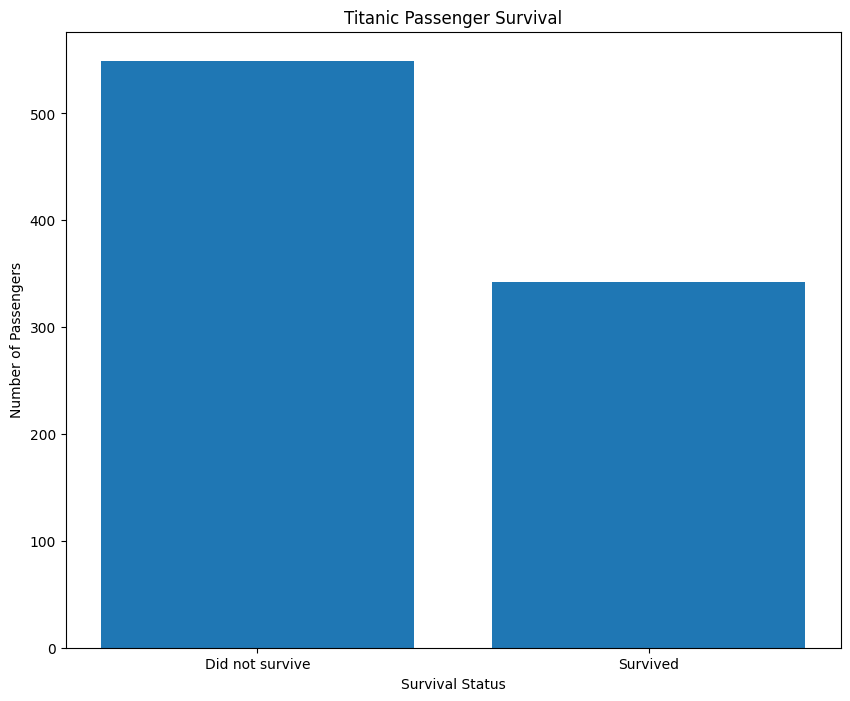

In [20]:
# Baseline visualization - barchart
survival_counts = df['Survived'].value_counts()

plt.figure(figsize=(10,8))
plt.bar(
    ['Did not survive', 'Survived'],
    survival_counts
)

plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.title('Titanic Passenger Survival')
plt.show()

### 2. Did survival rates differ between male and female passengers?

In [21]:
df.groupby('Sex')['Survived'].mean()*100
# Because Survived is 0/1, its mean represents the proportion that survived.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

- Survival rates differ based on gender. There were more female survivors (74.2%) than male survivors(18.9%).

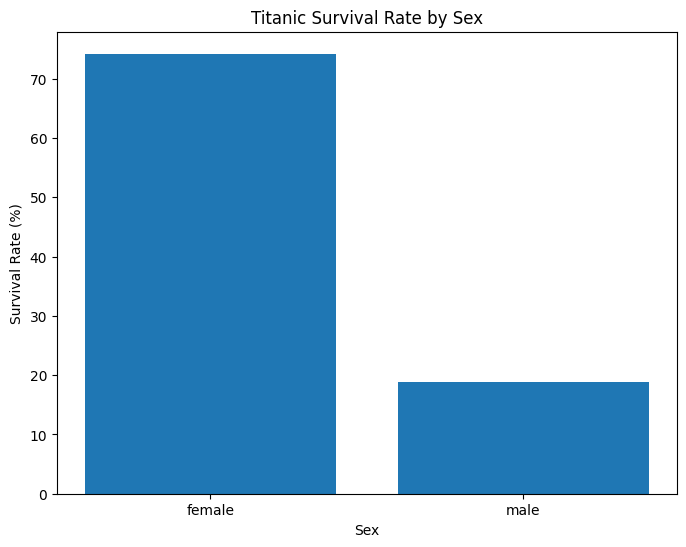

In [ ]:
# Survival rate by gender visualization
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    survival_by_sex.index,
    survival_by_sex.values
)

plt.xlabel('Sex')
plt.ylabel('Survival Rate (%)')
plt.title('Titanic Survival Rate by Sex')

plt.show()

### 3. Did passenger class relate to survival?

In [23]:
df.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

- Passenger class is visibly related to survival status. 1st class passengers had the highest survival rate (~63%), followed by 2nd class (47.3%) and finally 3rd class(24.2%).

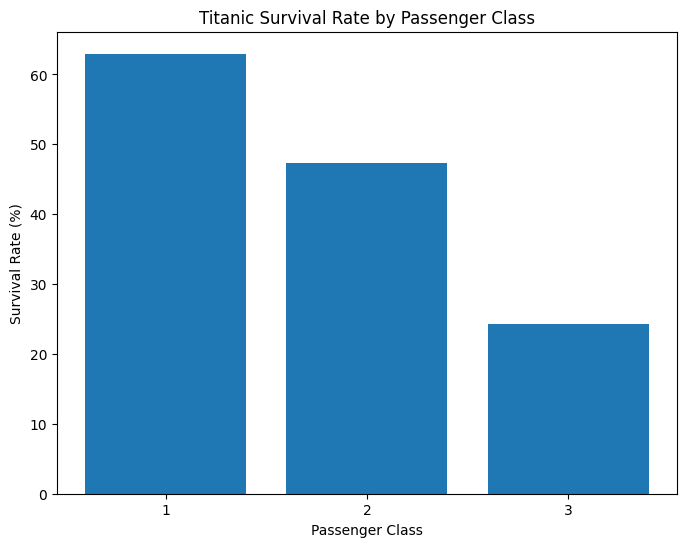

In [ ]:
# visualization of passenger class survival status
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values
)

plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.title('Titanic Survival Rate by Passenger Class')

plt.show()

### 4. How did survival vary when considering sex and passenger class together?

In [25]:
survival_sex_class = df.groupby(
    ['Pclass', 'Sex']
)['Survived'].mean() * 100

print(survival_sex_class)

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64


- Survival varies similarly to passenger class and gender, whereby 1st class passengers have the highest survival rate, with female passengers having the highest rates, and the trend goes gradually downward all the way to 3rd class but with noted higher rates for female passengers in all classes.

In [ ]:
# pivot table to compare both passenger class and sex in a matrix/tabular form
survival_pivot = df.pivot_table(
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc='mean'
) * 100

print(survival_pivot)

Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


### 5. How was passenger age distributed?

In [ ]:
# descriptive statistics for Age column
df['Age'].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

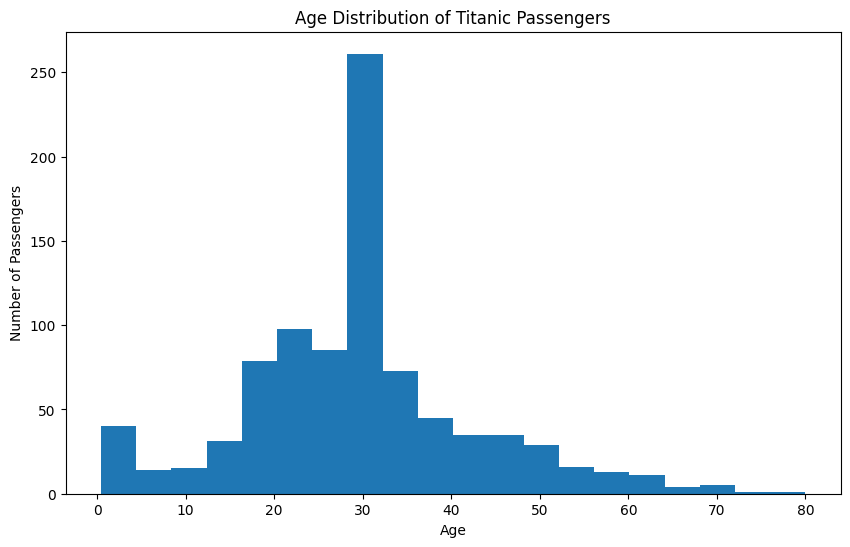

In [ ]:
# Age distribution plot
plt.figure(figsize=(10, 6))

plt.hist(df['Age'], bins=20)

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution of Titanic Passengers')

plt.show()

In [ ]:
# creating age groups and grouping by the divisions
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

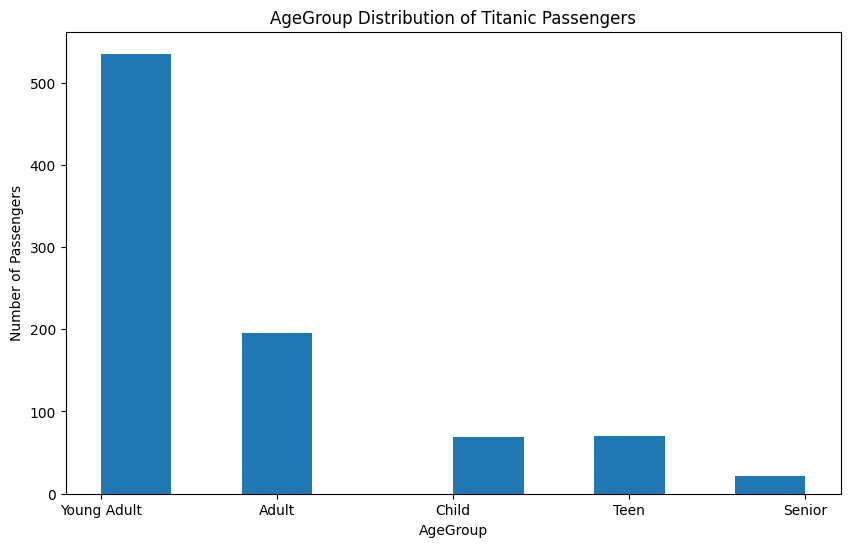

In [45]:
# Age distribution plot
plt.figure(figsize=(10, 6))

plt.hist(df['AgeGroup'], bins=10)

plt.xlabel('AgeGroup')
plt.ylabel('Number of Passengers')
plt.title('AgeGroup Distribution of Titanic Passengers')

plt.show()

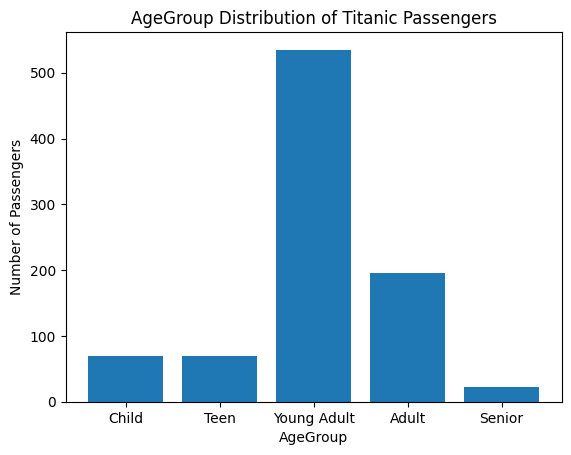

In [46]:
age_order = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

age_counts = df['AgeGroup'].value_counts().reindex(age_order)

plt.bar(age_counts.index, age_counts.values)

plt.xlabel('AgeGroup')
plt.ylabel('Number of Passengers')
plt.title('AgeGroup Distribution of Titanic Passengers')

plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_13528\2005549163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_distribution = df.groupby('AgeGroup')['Survived'].mean() * 100


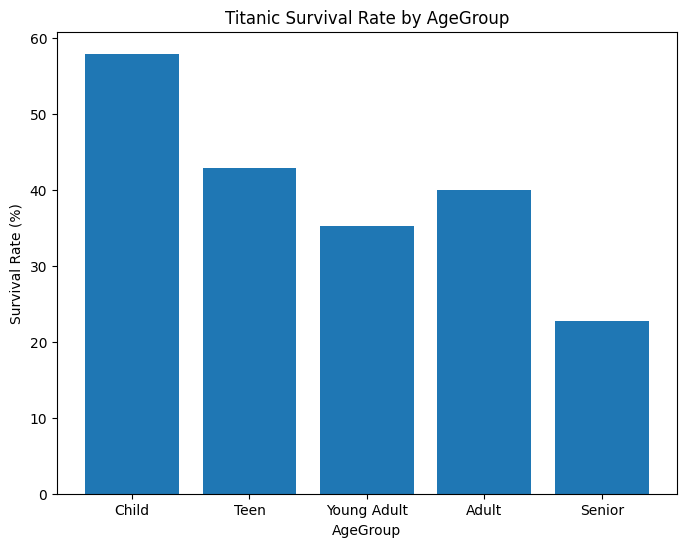

In [ ]:
# Survival rate by AgeGroup visualization
age_distribution = df.groupby('AgeGroup')['Survived'].mean() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    age_distribution.index,
    age_distribution.values
)

plt.xlabel('AgeGroup')
plt.ylabel('Survival Rate (%)')
plt.title('Titanic Survival Rate by AgeGroup')

plt.show()

### 6. Was passenger fare associated with survival?

In [30]:
df.groupby('Survived')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


**Mean**
- Passengers who did not survive paid an average fare of: £22.12
- Passengers who survived paid an average fare of: £48.40
**That's more than twice as high.**  This suggests that higher fares were associated with higher survival in this dataset.

**Median**
- The median is particularly useful here because Titanic fares are quite skewed — a relatively small number of passengers paid very high fares.
- For passengers who didn't survive:
    - Median fare = £10.50
- For passengers who survived:
    - Median fare = £26.00
- This is important because the median represents the middle passenger when fares are ordered from lowest to highest.
- So the typical surviving passenger paid a considerably higher fare than the typical passenger who didn't survive.

*The analysis indicates an association between passenger fare and survival. Survivors had a substantially higher mean fare (£48.40) compared with non-survivors (£22.12). The median fare was also higher among survivors (£26.00) than non-survivors (£10.50), suggesting that passengers who paid higher fares tended to have higher survival rates. However, this descriptive analysis identifies an association rather than establishing that higher fares directly caused greater survival.*

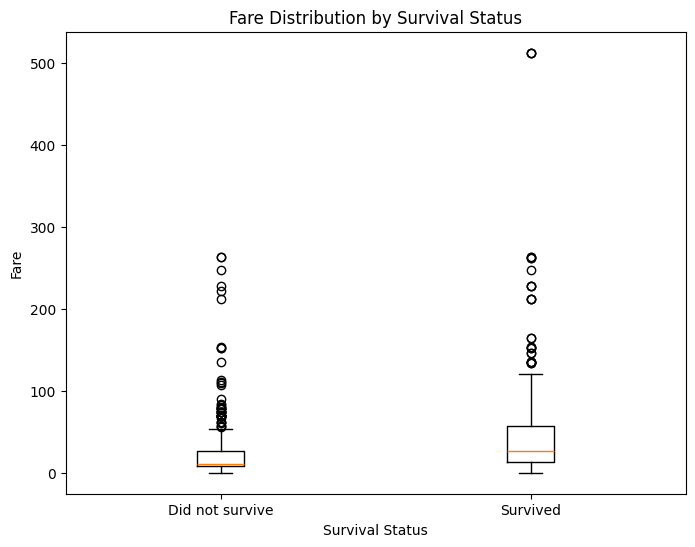

In [ ]:
# plot of fare by survival status
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        df[df['Survived'] == 0]['Fare'],
        df[df['Survived'] == 1]['Fare']
    ],
    tick_labels=['Did not survive', 'Survived']
)

plt.xlabel('Survival Status')
plt.ylabel('Fare')
plt.title('Fare Distribution by Survival Status')

plt.show()

- The survivor group has a much larger standard deviation/skew, meaning their fares were more widely dispersed.
- This makes sense because some surviving passengers paid very high fares.

### 7. Was family size associated with survival?

In [32]:
df.groupby("SibSp")['Survived'].mean()*100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

In [57]:
df['SibSp'].value_counts().sort_index()

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

- Survival varied according to the number of siblings or spouses aboard. Passengers with one sibling or spouse had the highest observed survival rate (53.6%), followed by those with two (46.4%). Survival rates were lower among passengers traveling with three or more siblings or spouses. However, the categories with higher SibSp values likely contain relatively few passengers, so their survival rates should be interpreted cautiously. Overall, the results suggest that the relationship between family size and survival was not simply linear.

In [58]:
# combine the count and survival rate
sibsp_analysis = df.groupby('SibSp')['Survived'].agg(
    passengers='count',
    survival_rate='mean'
)

sibsp_analysis['survival_rate'] *= 100

sibsp_analysis

,passengers,survival_rate
SibSp,,
0,608,34.539474
1,209,53.588517
2,28,46.428571
3,16,25.000000
4,18,16.666667
5,5,0.000000
8,7,0.000000


In [ ]:
# Parch means the number of parents or children a passenger had aboard the Titanic
df.groupby('Parch')['Survived'].mean() * 100

Parch
0    34.365782
1    55.084746
2    50.000000
3    60.000000
4     0.000000
5    20.000000
6     0.000000
Name: Survived, dtype: float64

In [59]:
df['Parch'].value_counts().sort_index()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

- Survival rates varied according to the number of parents or children aboard. Passengers traveling with 1–3 parents or children generally had higher survival rates than passengers traveling without parents or children. However, survival rates declined substantially for passengers with four or more parents or children aboard. The higher Parch categories likely contain relatively few observations, so these percentages should be interpreted cautiously.

In [34]:
# Create family size variable
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FamilySize'].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

In [35]:
df.groupby('FamilySize')['Survived'].mean() * 100

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

- A family size of 2-4 members had a higher survival rate compared to the other family sizes. Survival rates sharply dropped for families greater than 5 and those with one person only. Higher family size values should be interpreted cautiously due to their low occurrence rates aboard the ship

In [36]:
# Numerical correlations
correlation_matrix = df[
    ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
].corr()

print(correlation_matrix)

          Survived       Age      Fare     SibSp     Parch    Pclass
Survived  1.000000 -0.069809  0.257307 -0.035322  0.081629 -0.338481
Age      -0.069809  1.000000  0.091566 -0.232625 -0.179191 -0.331339
Fare      0.257307  0.091566  1.000000  0.159651  0.216225 -0.549500
SibSp    -0.035322 -0.232625  0.159651  1.000000  0.414838  0.083081
Parch     0.081629 -0.179191  0.216225  0.414838  1.000000  0.018443
Pclass   -0.338481 -0.331339 -0.549500  0.083081  0.018443  1.000000


- Correlation Analysis: The correlation matrix reveals that Pclass has the strongest linear association with survival among the numerical variables, with a correlation of -0.338. Since lower Pclass values represent higher passenger classes, this negative relationship suggests that passengers in higher classes were more likely to survive. Fare also shows a weak positive correlation with survival (0.257), potentially reflecting differences in passenger class. Age, SibSp, and Parch exhibit very weak correlations with survival, suggesting limited linear relationships. Additionally, Fare and Pclass have a relatively strong negative correlation (-0.550), indicating that passengers in higher classes generally paid higher fares.

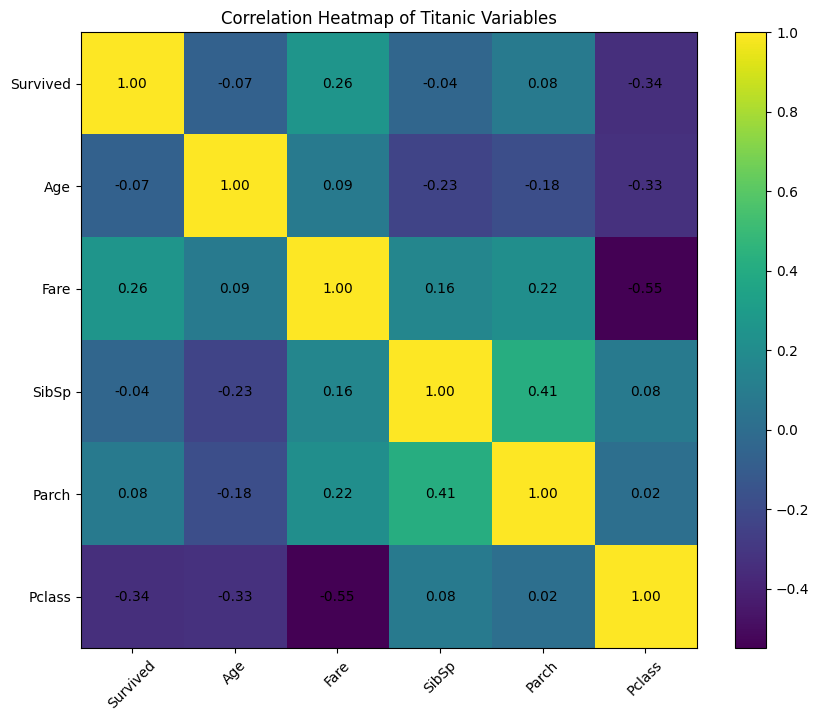

In [60]:
# correlation heatmap
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap of Titanic Variables')

plt.show()

## Key Findings and Conclusions

## Key Findings

The exploratory analysis of the Titanic dataset revealed several notable patterns:

- **Survival rate:** A relatively small proportion of passengers survived, indicating that the majority of passengers did not survive the disaster.

- **Sex:** Survival differed substantially by sex. Female passengers had a considerably higher survival rate than male passengers.

- **Passenger class:** Survival also varied considerably across passenger classes. First-class passengers generally had higher survival rates than second- and third-class passengers.

- **Sex and passenger class:** The combination of sex and passenger class revealed further differences in survival. Female passengers generally had higher survival rates across classes, while male passengers, particularly those in lower classes, had substantially lower survival rates.

- **Age:** The age distribution showed that passengers represented a wide range of ages. Survival patterns varied across age groups, although age showed a relatively weak linear correlation with survival.

- **Fare:** Passengers who paid higher fares tended to have higher survival rates. Fare had a positive correlation with survival.

- **Family relationships:** Variables such as *SibSp* and *Parch* showed that family circumstances were also related to survival, although their relationships with survival were relatively weak.

- **Correlation:** Among the numerical variables examined, *Pclass* and *Fare* showed some of the stronger relationships with survival. The negative correlation between *Pclass* and *Fare* also reflects the relationship between passenger class and ticket price.

## Conclusion

This exploratory analysis investigated the characteristics associated with passenger survival on the Titanic. The analysis found that survival was not evenly distributed among passengers and that substantial differences existed according to sex and passenger class.

Female passengers generally had higher survival rates than male passengers, while passengers in higher classes generally experienced higher survival rates than those in lower classes. Fare was also positively associated with survival, which is consistent with the relationship between fare and passenger class observed in the correlation analysis.

Age, family-related variables, and other numerical characteristics showed weaker relationships with survival when considered individually. However, the analysis demonstrates that examining variables together can provide a more complete understanding of the patterns present in the dataset.

Overall, the findings suggest that passenger sex and socioeconomic status, represented partly by passenger class and fare, were among the characteristics most strongly associated with survival in this dataset. However, these results describe associations within the dataset and should not be interpreted as evidence that any individual characteristic directly caused a passenger to survive or not survive.

## Future Work

This analysis focused primarily on exploratory data analysis and identifying patterns in passenger survival. Further analysis could extend the project by developing a machine learning classification model to predict survival based on passenger characteristics.

Potential next steps include:

- Encoding categorical variables such as `Sex` and `Embarked`
- Engineering additional features such as `FamilySize`
- Handling remaining missing values appropriately
- Splitting the data into training and testing sets
- Training classification models such as Logistic Regression, Decision Tree, Random Forest, or XGBoost
- Evaluating model performance using appropriate classification metrics
- Comparing model predictions with the patterns identified during EDA